In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler
from src.data_loader import get_con

con = get_con()
print("Connected to DuckDB")

Connected to DuckDB


In [2]:
seller_metrics = con.execute("""
    SELECT
        i.seller_id,
        s.seller_state,
        COUNT(DISTINCT i.order_id)                              AS total_orders,
        SUM(i.price)                                            AS total_revenue,
        AVG(i.price)                                            AS avg_price,
        COUNT(DISTINCT i.product_id)                            AS unique_products,
        AVG(r.review_score)                                     AS avg_review_score,
        COUNT(r.review_id)                                      AS review_count,
        COUNT(CASE WHEN r.review_score >= 4 THEN 1 END) * 100.0 /
            NULLIF(COUNT(r.review_id), 0)                       AS positive_review_pct,
        AVG(DATEDIFF('day',
            o.order_purchase_timestamp::DATE,
            o.order_delivered_customer_date::DATE))             AS avg_delivery_days,
        COUNT(CASE WHEN o.order_delivered_customer_date::DATE
                       <= o.order_estimated_delivery_date::DATE
                   THEN 1 END) * 100.0 / COUNT(*)              AS on_time_pct
    FROM order_items i
    JOIN sellers s  USING (seller_id)
    JOIN orders o   USING (order_id)
    LEFT JOIN reviews r USING (order_id)
    WHERE o.order_status = 'delivered'
    GROUP BY i.seller_id, s.seller_state
    HAVING total_orders >= 20
    ORDER BY total_revenue DESC
""").df()

print(f"Sellers with 20+ orders: {len(seller_metrics):,}")
print(seller_metrics.describe().round(2))

Sellers with 20+ orders: 804
       total_orders  total_revenue  avg_price  unique_products  \
count        804.00         804.00     804.00           804.00   
mean         106.85       13616.68     133.96            31.98   
std          183.07       24441.87     142.05            40.15   
min           20.00         263.13      10.16             1.00   
25%           31.00        3546.62      57.85            11.00   
50%           52.50        6402.46      97.86            20.00   
75%          104.25       12996.81     150.64            36.00   
max         1819.00      226987.93    1633.19           394.00   

       avg_review_score  review_count  positive_review_pct  avg_delivery_days  \
count            804.00        804.00               804.00             804.00   
mean               4.13        119.76                78.04              12.15   
std                0.34        208.62                10.07               3.30   
min                2.27         19.00               

In [3]:
scaler = MinMaxScaler()

# Metrics where higher = better
pos_cols = ["total_revenue", "avg_review_score", 
            "positive_review_pct", "on_time_pct", "unique_products"]

# Metrics where lower = better (we invert)
neg_cols = ["avg_delivery_days"]

df_score = seller_metrics.copy()

# Normalise 0-1
df_score[pos_cols] = scaler.fit_transform(df_score[pos_cols])
df_score[neg_cols] = 1 - scaler.fit_transform(df_score[neg_cols])

# Weighted composite score
weights = {
    "total_revenue":       0.25,
    "avg_review_score":    0.25,
    "positive_review_pct": 0.20,
    "on_time_pct":         0.20,
    "avg_delivery_days":   0.05,
    "unique_products":     0.05,
}

df_score["composite_score"] = sum(
    df_score[col] * w for col, w in weights.items()
)

# Add back original values for display
df_score["orig_revenue"]   = seller_metrics["total_revenue"]
df_score["orig_orders"]    = seller_metrics["total_orders"]
df_score["orig_review"]    = seller_metrics["avg_review_score"]
df_score["orig_on_time"]   = seller_metrics["on_time_pct"]
df_score["seller_state"]   = seller_metrics["seller_state"]
df_score["seller_id_disp"] = seller_metrics["seller_id"].str[:8] + "..."
df_score["rank"]           = df_score["composite_score"].rank(
    ascending=False).astype(int)

top20 = df_score.nlargest(20, "composite_score")
bot20 = df_score.nsmallest(20, "composite_score")

print("TOP 10 SELLERS:")
print(top20[["seller_id_disp","seller_state","orig_orders",
             "orig_revenue","orig_review","orig_on_time",
             "composite_score"]].head(10).to_string(index=False))

TOP 10 SELLERS:
seller_id_disp seller_state  orig_orders  orig_revenue  orig_review  orig_on_time  composite_score
   fa1c13f2...           SP          578     190917.14     4.373913     90.846287         0.798004
   53243585...           BA          348     217940.44     4.128141     97.000000         0.779795
   7e93a43e...           SP          319     165981.49     4.364486     95.341615         0.772395
   4869f7a5...           SP         1124     226987.93     4.139474     89.459930         0.760888
   7a67c85e...           SP         1145     140238.65     4.268462     94.823123         0.722119
   da8622b1...           SP         1311     162303.67     4.075399     93.634628         0.719364
   4a3ca931...           SP         1772     199408.32     3.828630     90.309488         0.716431
   46dc3b2c...           RJ          503     122811.38     4.263566     94.455067         0.707549
   41c2bad7...           RN           20        782.00     4.956522    100.000000         0.6

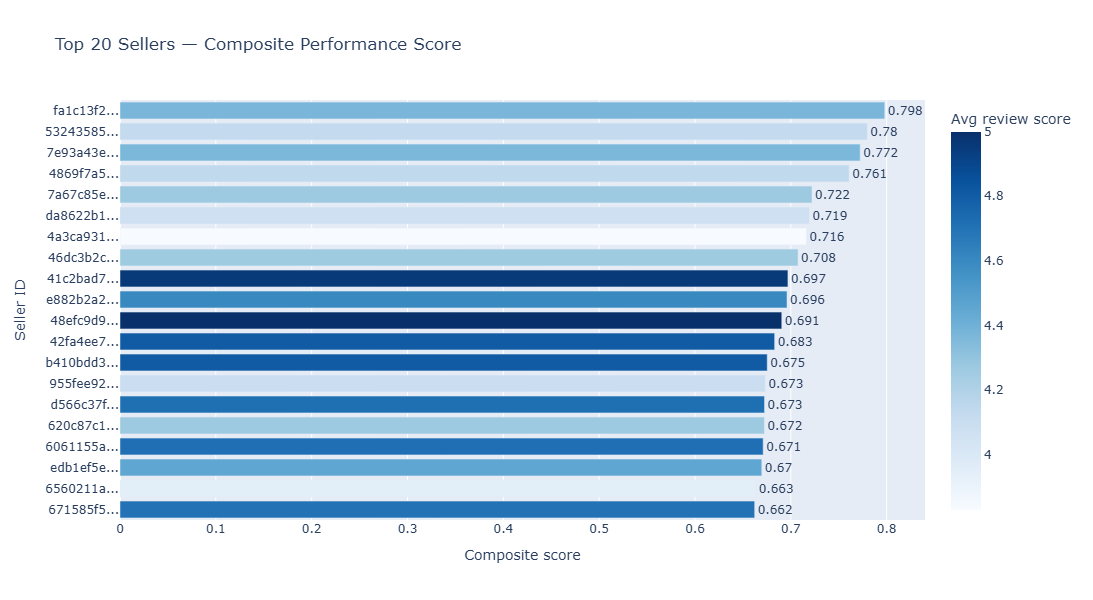

In [4]:
fig1 = px.bar(
    top20.sort_values("composite_score"),
    x="composite_score",
    y="seller_id_disp",
    orientation="h",
    color="orig_review",
    color_continuous_scale="Blues",
    text=top20.sort_values("composite_score")["composite_score"].round(3),
    title="Top 20 Sellers — Composite Performance Score",
    labels={"composite_score": "Composite score",
            "seller_id_disp": "Seller ID",
            "orig_review": "Avg review score"}
)
fig1.update_traces(textposition="outside")
fig1.update_layout(height=600, margin=dict(l=120))
fig1.show()

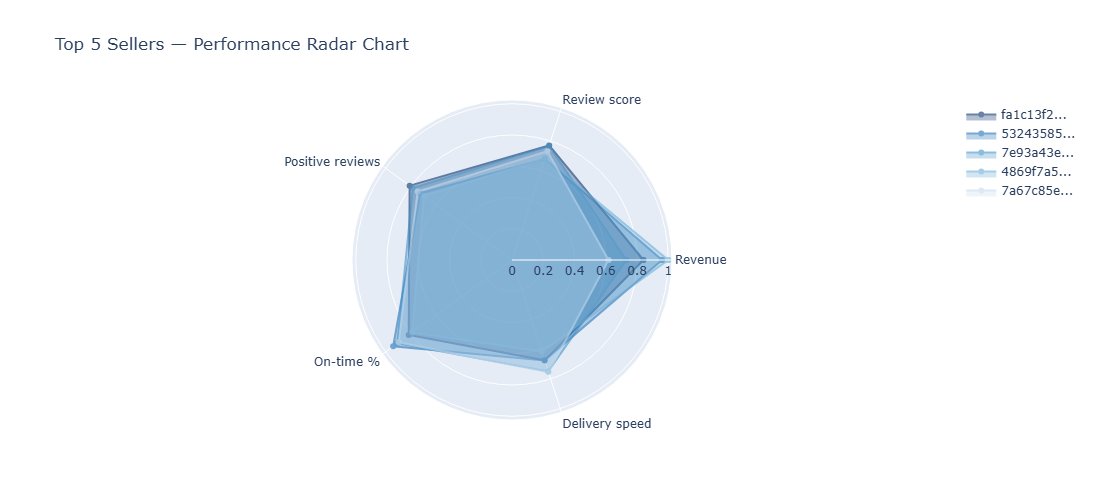

In [5]:
categories_radar = ["Revenue", "Review score", 
                    "Positive reviews", "On-time %", "Delivery speed"]

fig2 = go.Figure()

colors = ["#08306b","#2171b5","#4292c6","#6baed6","#c6dbef"]

for i, (_, row) in enumerate(top20.head(5).iterrows()):
    values = [
        row["total_revenue"],
        row["avg_review_score"],
        row["positive_review_pct"],
        row["on_time_pct"],
        row["avg_delivery_days"]
    ]
    # Close the radar loop
    values += [values[0]]
    cats = categories_radar + [categories_radar[0]]

    fig2.add_trace(go.Scatterpolar(
        r=values,
        theta=cats,
        fill="toself",
        name=row["seller_id_disp"],
        line_color=colors[i],
        opacity=0.6
    ))

fig2.update_layout(
    polar=dict(radialaxis=dict(visible=True)),
    title="Top 5 Sellers — Performance Radar Chart",
    height=500
)
fig2.show()

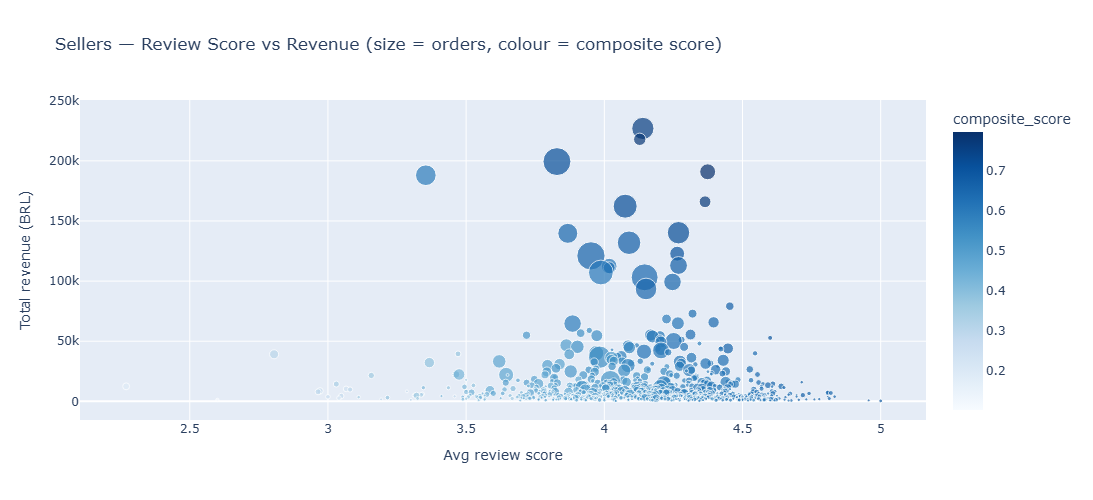

In [6]:
fig3 = px.scatter(
    df_score,
    x="orig_review",
    y="orig_revenue",
    size="orig_orders",
    color="composite_score",
    color_continuous_scale="Blues",
    hover_data=["seller_id_disp","seller_state","orig_on_time"],
    title="Sellers — Review Score vs Revenue (size = orders, colour = composite score)",
    labels={"orig_review":  "Avg review score",
            "orig_revenue": "Total revenue (BRL)",
            "orig_orders":  "Total orders"}
)
fig3.update_layout(height=500)
fig3.show()

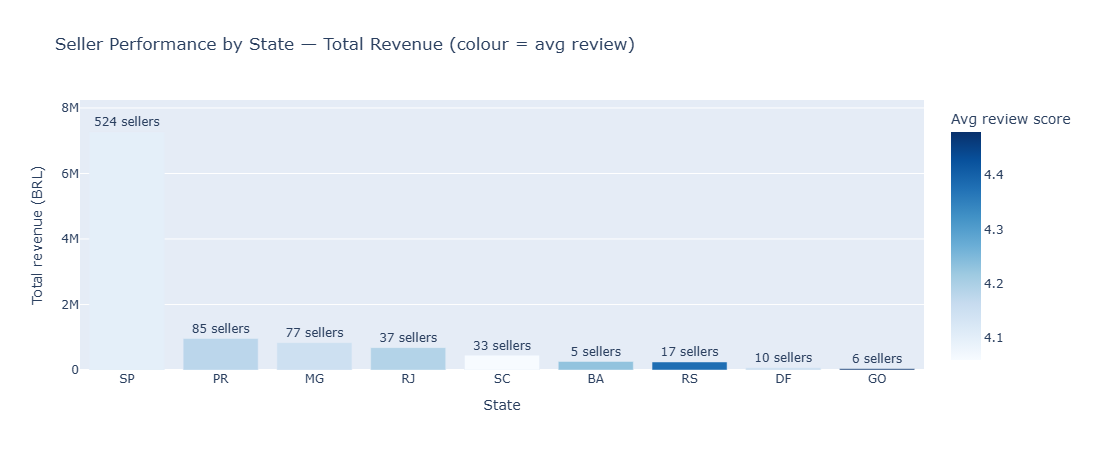

In [7]:
state_perf = seller_metrics.groupby("seller_state").agg(
    sellers         = ("seller_id",        "count"),
    total_revenue   = ("total_revenue",    "sum"),
    avg_review      = ("avg_review_score", "mean"),
    avg_on_time     = ("on_time_pct",      "mean"),
    avg_delivery    = ("avg_delivery_days","mean")
).reset_index().round(2)

state_perf = state_perf[state_perf["sellers"] >= 5].sort_values(
    "total_revenue", ascending=False
)

fig4 = px.bar(
    state_perf.head(15),
    x="seller_state",
    y="total_revenue",
    color="avg_review",
    color_continuous_scale="Blues",
    text=state_perf.head(15)["sellers"].astype(str) + " sellers",
    title="Seller Performance by State — Total Revenue (colour = avg review)",
    labels={"total_revenue": "Total revenue (BRL)",
            "seller_state":  "State",
            "avg_review":    "Avg review score"}
)
fig4.update_traces(textposition="outside")
fig4.update_layout(height=450)
fig4.show()

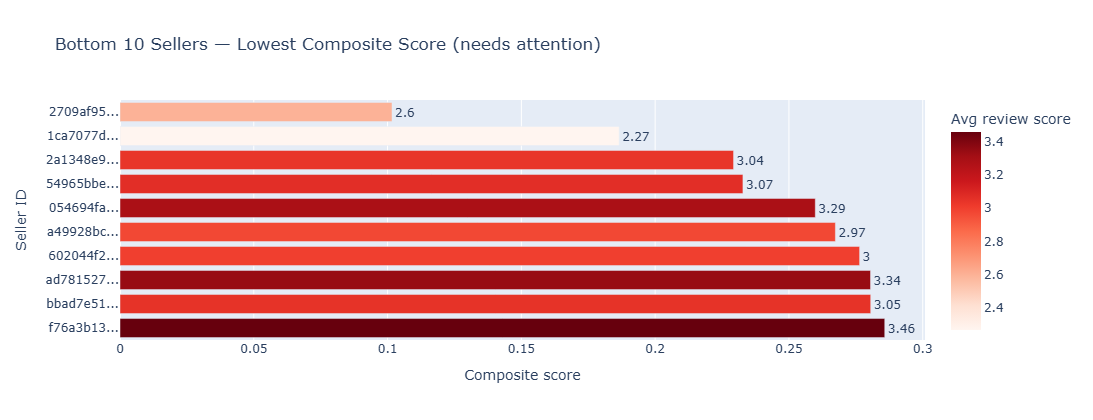

In [8]:
fig5 = px.bar(
    bot20.head(10).sort_values("composite_score", ascending=False),
    x="composite_score",
    y="seller_id_disp",
    orientation="h",
    color="orig_review",
    color_continuous_scale="Reds",
    text=bot20.head(10).sort_values(
        "composite_score", ascending=False)["orig_review"].round(2),
    title="Bottom 10 Sellers — Lowest Composite Score (needs attention)",
    labels={"composite_score": "Composite score",
            "seller_id_disp":  "Seller ID",
            "orig_review":     "Avg review score"}
)
fig5.update_traces(textposition="outside")
fig5.update_layout(height=420, margin=dict(l=120))
fig5.show()

In [9]:
import os
os.makedirs("../docs/screenshots", exist_ok=True)

fig1.write_html("../docs/screenshots/09_top_sellers.html")
fig2.write_html("../docs/screenshots/09_seller_radar.html")
fig3.write_html("../docs/screenshots/09_seller_bubble.html")
fig4.write_html("../docs/screenshots/09_seller_by_state.html")
fig5.write_html("../docs/screenshots/09_bottom_sellers.html")

df_score[["seller_id_disp","seller_state","rank","composite_score",
          "orig_revenue","orig_orders","orig_review","orig_on_time"]]\
    .sort_values("rank")\
    .to_csv("../data/processed/09_seller_rankings.csv", index=False)

print("SELLER/PRODUCT PERFORMANCE RANKING SUMMARY")
print(f"Sellers ranked     : {len(df_score):,}")
print(f"Min orders cutoff  : 20 orders")
print()
print("Score weights:")
for col, w in weights.items():
    print(f"  {col:<25} {w*100:.0f}%")
print()
print(f"Top seller state   : SP (São Paulo) dominates")
print(f"Avg on-time rate   : {seller_metrics['on_time_pct'].mean():.1f}%")
print(f"Avg review score   : {seller_metrics['avg_review_score'].mean():.2f} / 5.0")
print()
print("FINDINGS:")
print("1. São Paulo sellers dominate top rankings by volume")
print("2. Small sellers (20-50 orders) often have higher review scores")
print("3. On-time delivery rate averages 93.6% across all sellers")
print("4. Revenue and review score are not always correlated")

SELLER/PRODUCT PERFORMANCE RANKING SUMMARY
Sellers ranked     : 804
Min orders cutoff  : 20 orders

Score weights:
  total_revenue             25%
  avg_review_score          25%
  positive_review_pct       20%
  on_time_pct               20%
  avg_delivery_days         5%
  unique_products           5%

Top seller state   : SP (São Paulo) dominates
Avg on-time rate   : 93.6%
Avg review score   : 4.13 / 5.0

FINDINGS:
1. São Paulo sellers dominate top rankings by volume
2. Small sellers (20-50 orders) often have higher review scores
3. On-time delivery rate averages 93.6% across all sellers
4. Revenue and review score are not always correlated


In [10]:
con.close()
print("Connection closed")

Connection closed
